# Inference analysis

In [ ]:

import pandas as pd
#Read json data file
#list every json in static folder
static_folder = '/Users/pierre/ikaros/Source/Modules/RobotModules/CompliantRobot/TestMapping/results/static_mode/ANN'
import os
static_json_files = [f for f in os.listdir(static_folder) if f.endswith('.json')]

#make df of all jsons
static_data_df = pd.DataFrame()
for json_file in static_json_files:
    file_name = json_file.replace('.json', '')
    with open(os.path.join(static_folder, json_file), 'r') as f:
        data = pd.read_json(f, typ='frame')
        
        data_df = pd.DataFrame(data['static_push_data'].tolist())
        data_df['source'] = file_name  # Add model name column

        static_data_df = pd.concat([static_data_df, data_df], ignore_index=True)
        

moving_folder ='/Users/pierre/ikaros/Source/Modules/RobotModules/CompliantRobot/TestMapping/results/moving_mode/ANN'
moving_json_files = [f for f in os.listdir(moving_folder) if f.endswith('.json')]
moving_data_df = pd.DataFrame()
for json_file in moving_json_files:
    file_name = json_file.replace('.json', '')
    with open(os.path.join(moving_folder, json_file), 'r') as f:
        data = pd.read_json(f, typ='frame')
        data_df = pd.DataFrame(data['deviance_data'].tolist())
        data_df['source'] = file_name  # Add model name column

        moving_data_df = pd.concat([moving_data_df, data_df], ignore_index=True)
moving_data_df['source']

static_data_df['sequence_id'] = static_data_df['source'] + '_T' + static_data_df['transition'].astype(str)
moving_data_df['sequence_id'] = moving_data_df['source'] + '_T' + moving_data_df['transition'].astype(str)
combined_df_original = pd.concat([static_data_df, moving_data_df], ignore_index=True)
# Verify the new column
print("Static data unique sequences:", static_data_df['sequence_id'].nunique())
print("Moving data unique sequences:", moving_data_df['sequence_id'].nunique())
print("Combined data unique sequences:", combined_df_original['sequence_id'].nunique())




Static data unique sequences: 360
Moving data unique sequences: 662
Combined data unique sequences: 1022


In [ ]:
combined_df_original.head()

,transition,tick,time,pertubation_type,phase_elapsed,present_position,goal_position,present_current,model_prediction,gyro,accel,euler_angles,source,sequence_id,starting_positions
0,0,42,1.050,push,0.024,"[200.3027, 233.1738]","[200.0, 234.0]","[-90.72, 255.36]","[154.5116, 303.0052]","[-0.4979, -0.0014, -0.48850000000000005]","[-0.12390000000000001, -0.2069, -0.92670000000...","[12.2388, -7.251, -271.4172]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,NaN
1,0,43,1.075,push,0.049,"[200.3027, 233.1738]","[200.0, 234.0]","[-94.08, 255.36]","[154.9825, 302.9903]","[0.6649, 0.6711, -0.3372]","[-0.1282, -0.2059, -0.9252]","[12.2607, -7.251, -271.4392]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,NaN
2,0,44,1.100,push,0.074,"[200.3027, 233.1738]","[200.0, 234.0]","[-94.08, 252.0]","[154.6819, 302.9979]","[0.1477, -0.0308, -0.4268]","[-0.12840000000000001, -0.2187, -0.9241]","[12.2937, -7.2620000000000005, -271.4392]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,NaN
3,0,45,1.125,push,0.099,"[200.3027, 233.1738]","[200.0, 234.0]","[-94.08, 258.72]","[155.0266, 300.0121]","[-1.4385000000000001, 1.5529, 0.24250000000000...","[-0.1342, -0.225, -0.9235000000000001]","[12.3596, -7.2949, -271.4612]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,NaN
4,0,46,1.150,push,0.124,"[200.3027, 233.1738]","[200.0, 234.0]","[-94.08, 252.0]","[154.1277, 305.9879]","[-1.7856, 1.8293000000000001, -0.0689]","[-0.1361, -0.223, -0.9228000000000001]","[12.3926, -7.3059, -271.4502]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,NaN


In [ ]:
combined_df = combined_df_original.copy()
#correct typos in pertubation_type column name 
combined_df.rename(columns={'pertubation_type':'perturbation_type'}, inplace=True)

#The model_prediciton is really the prediction of last step, move every row one step forward
combined_df['model_prediction'] = combined_df.groupby('sequence_id')['model_prediction'].shift(-1)
#Make feature coloumns from present_current and model_prediction
combined_df['tilt_current'] = combined_df['present_current'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
combined_df['pan_current'] = combined_df['present_current'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
combined_df['tilt_prediction'] = combined_df['model_prediction'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
combined_df['pan_prediction'] = combined_df['model_prediction'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan) 
combined_df['tilt_error'] = combined_df['tilt_current'] - combined_df['tilt_prediction']
combined_df['pan_error'] = combined_df['pan_current'] - combined_df['pan_prediction']

combined_df.drop(columns=['model_prediction', 'present_current', 'starting_positions'], inplace=True)
                                 

In [ ]:
combined_df.head()

,transition,tick,time,perturbation_type,phase_elapsed,present_position,goal_position,gyro,accel,euler_angles,source,sequence_id,tilt_current,pan_current,tilt_prediction,pan_prediction,tilt_error,pan_error
0,0,42,1.050,push,0.024,"[200.3027, 233.1738]","[200.0, 234.0]","[-0.4979, -0.0014, -0.48850000000000005]","[-0.12390000000000001, -0.2069, -0.92670000000...","[12.2388, -7.251, -271.4172]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,-90.72,255.36,154.9825,302.9903,-245.7025,-47.6303
1,0,43,1.075,push,0.049,"[200.3027, 233.1738]","[200.0, 234.0]","[0.6649, 0.6711, -0.3372]","[-0.1282, -0.2059, -0.9252]","[12.2607, -7.251, -271.4392]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,-94.08,255.36,154.6819,302.9979,-248.7619,-47.6379
2,0,44,1.100,push,0.074,"[200.3027, 233.1738]","[200.0, 234.0]","[0.1477, -0.0308, -0.4268]","[-0.12840000000000001, -0.2187, -0.9241]","[12.2937, -7.2620000000000005, -271.4392]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,-94.08,252.00,155.0266,300.0121,-249.1066,-48.0121
3,0,45,1.125,push,0.099,"[200.3027, 233.1738]","[200.0, 234.0]","[-1.4385000000000001, 1.5529, 0.24250000000000...","[-0.1342, -0.225, -0.9235000000000001]","[12.3596, -7.2949, -271.4612]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,-94.08,258.72,154.1277,305.9879,-248.2077,-47.2679
4,0,46,1.150,push,0.124,"[200.3027, 233.1738]","[200.0, 234.0]","[-1.7856, 1.8293000000000001, -0.0689]","[-0.1361, -0.223, -0.9228000000000001]","[12.3926, -7.3059, -271.4502]",tilt_static_mode_log_20251021_090723_push,tilt_static_mode_log_20251021_090723_push_T0,-94.08,252.00,154.6452,300.0728,-248.7252,-48.0728


# Perturbation Classification Model

## Goal
Train a model to classify perturbation types:
- Push
- Obstacle  
- Sustained force
- None (no perturbation)

Based on:
- Present current
- Prediction error (model_prediction - present_current)

# Sequence-Based Perturbation Classification

This section analyzes the data as sequences and builds a classifier that can handle temporal patterns within each sequence.

In [ ]:
# Step 1: Analyze sequence structure in combined_df
print("=== Sequence Data Analysis ===\n")

# Check if sequence_id exists
if 'sequence_id' not in combined_df.columns:
    print("WARNING: 'sequence_id' column not found. Available columns:")
    print(combined_df.columns.tolist())
else:
    # Basic sequence statistics
    n_sequences = combined_df['sequence_id'].nunique()
    print(f"Total number of sequences: {n_sequences}")
    
    # Sequence length statistics
    seq_lengths = combined_df.groupby('sequence_id').size()
    print(f"\nSequence length statistics:")
    print(f"  Min length: {seq_lengths.min()}")
    print(f"  Max length: {seq_lengths.max()}")
    print(f"  Mean length: {seq_lengths.mean():.2f}")
    print(f"  Median length: {seq_lengths.median():.0f}")
    
    # Perturbation type distribution
    if 'perturbation_type' in combined_df.columns:
        # Get one row per sequence to count perturbation types
        sequence_info = combined_df.groupby('sequence_id').first()
        print(f"\n=== Perturbation Type Distribution ===")
        print(sequence_info['perturbation_type'].value_counts())
        print(f"\nPercentage breakdown:")
        print(sequence_info['perturbation_type'].value_counts(normalize=True) * 100)
    else:
        print("\nWARNING: 'perturbation_type' column not found")

=== Sequence Data Analysis ===

Total number of sequences: 1022

Sequence length statistics:
  Min length: 34
  Max length: 220
  Mean length: 68.59
  Median length: 67

=== Perturbation Type Distribution ===
perturbation_type
obstacle     362
none         300
push         210
sustained    150
Name: count, dtype: int64

Percentage breakdown:
perturbation_type
obstacle     35.420744
none         29.354207
push         20.547945
sustained    14.677104
Name: proportion, dtype: float64


In [ ]:
# Step 2: Prepare sequence data for classification
# We need to ensure sequences are not split between train/test

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Extract features and labels
feature_cols = ['tilt_current', 'pan_current', 'tilt_error', 'pan_error']

# Check which columns exist
available_features = [col for col in feature_cols if col in combined_df.columns]
print(f"Available features: {available_features}")

if 'sequence_id' in combined_df.columns and 'perturbation_type' in combined_df.columns:
    # Prepare data
    X_sequences = combined_df[available_features].values
    y_sequences = combined_df['perturbation_type'].values
    groups = combined_df['sequence_id'].values
    
    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_sequences)
    
    print(f"\nClass mapping:")
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"  {i}: {class_name}")
    
    print(f"\nData shape: {X_sequences.shape}")
    print(f"Number of unique sequences: {len(np.unique(groups))}")
else:
    print("ERROR: Required columns not found")

Available features: ['tilt_current', 'pan_current', 'tilt_error', 'pan_error']

Class mapping:
  0: none
  1: obstacle
  2: push
  3: sustained

Data shape: (66101, 4)
Number of unique sequences: 972


In [ ]:
# Step 3: Split data using GroupShuffleSplit
# This ensures entire sequences stay together in either train or test set

if 'sequence_id' in combined_df.columns and 'perturbation_type' in combined_df.columns:
    # Use GroupShuffleSplit to split by sequence_id
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    
    # Get train and test indices
    train_idx, test_idx = next(gss.split(X_sequences, y_encoded, groups=groups))
    
    X_train = X_sequences[train_idx]
    X_test = X_sequences[test_idx]
    y_train = y_encoded[train_idx]
    y_test = y_encoded[test_idx]
    groups_train = groups[train_idx]
    groups_test = groups[test_idx]
    
    print(f"=== Train/Test Split ===")
    print(f"Train set: {len(X_train)} samples from {len(np.unique(groups_train))} sequences")
    print(f"Test set: {len(X_test)} samples from {len(np.unique(groups_test))} sequences")
    
    # Verify no sequence overlap
    train_sequences = set(np.unique(groups_train))
    test_sequences = set(np.unique(groups_test))
    overlap = train_sequences.intersection(test_sequences)
    print(f"\nSequence overlap check: {len(overlap)} sequences in both sets (should be 0)")
    
    # Check class distribution
    print(f"\n=== Class Distribution ===")
    print("Training set:")
    for i, class_name in enumerate(label_encoder.classes_):
        count = np.sum(y_train == i)
        pct = count / len(y_train) * 100
        print(f"  {class_name}: {count} ({pct:.1f}%)")
    
    print("\nTest set:")
    for i, class_name in enumerate(label_encoder.classes_):
        count = np.sum(y_test == i)
        pct = count / len(y_test) * 100
        print(f"  {class_name}: {count} ({pct:.1f}%)")

=== Train/Test Split ===
Train set: 52671 samples from 777 sequences
Test set: 13430 samples from 195 sequences

Sequence overlap check: 0 sequences in both sets (should be 0)

=== Class Distribution ===
Training set:
  none: 14445 (27.4%)
  obstacle: 18786 (35.7%)
  push: 13440 (25.5%)
  sustained: 6000 (11.4%)

Test set:
  none: 4043 (30.1%)
  obstacle: 4027 (30.0%)
  push: 3360 (25.0%)
  sustained: 2000 (14.9%)


## Approach 1: Simple Point-wise Classification with Sequence-aware Split

First, let's try a simple approach where we classify each time point independently, but ensure our train/test split respects sequence boundaries.

In [ ]:
# Train a Random Forest classifier (point-wise)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

if 'X_train' in locals():
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train Random Forest
    print("=== Training Random Forest Classifier ===")
    rf_model = RandomForestClassifier(
        n_estimators=50,  # Reduced for speed
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred_train = rf_model.predict(X_train_scaled)
    y_pred_test = rf_model.predict(X_test_scaled)
    
    # Evaluation
    train_acc = np.mean(y_pred_train == y_train)
    test_acc = np.mean(y_pred_test == y_test)
    
    print(f"\nTrain Accuracy: {train_acc:.2%}")
    print(f"Test Accuracy: {test_acc:.2%}")
    
    print("\n=== Classification Report (Test Set) ===")
    print(classification_report(y_test, y_pred_test, 
                                target_names=label_encoder.classes_,
                                digits=3))

=== Training Random Forest Classifier ===

Train Accuracy: 91.02%
Test Accuracy: 73.08%

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

        none      0.663     0.587     0.623      4043
    obstacle      0.589     0.715     0.646      4027
        push      0.965     0.979     0.972      3360
   sustained      0.820     0.635     0.716      2000

    accuracy                          0.731     13430
   macro avg      0.759     0.729     0.739     13430
weighted avg      0.740     0.731     0.731     13430



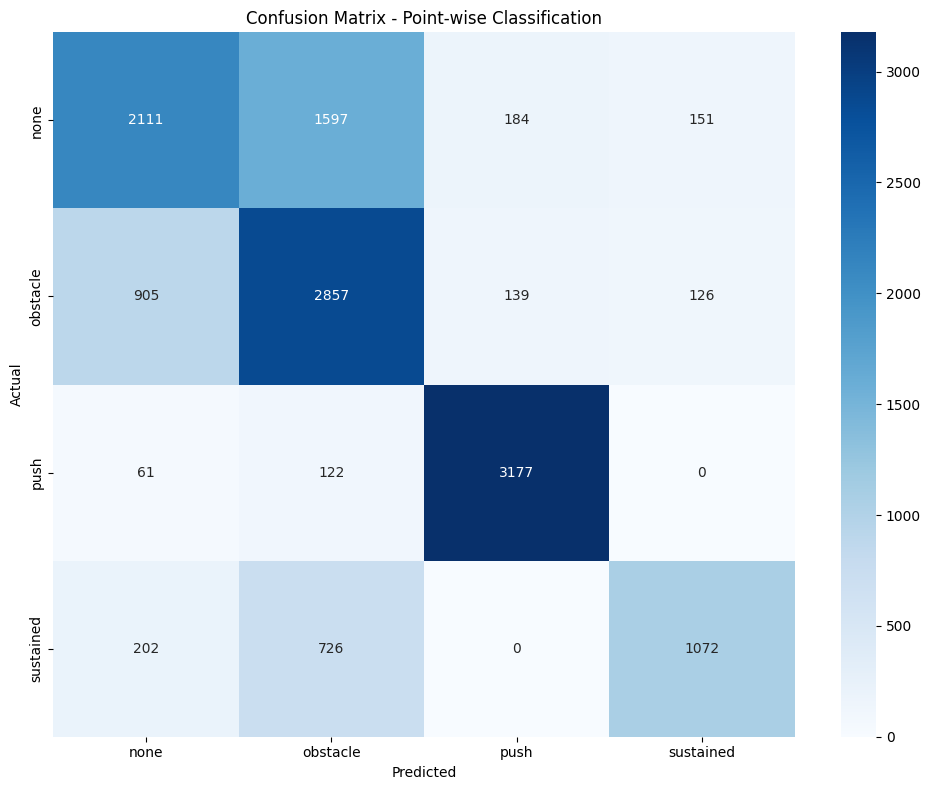


=== Feature Importance ===
        feature  importance
2    tilt_error    0.370416
0  tilt_current    0.285362
1   pan_current    0.220739
3     pan_error    0.123482


In [ ]:
# Confusion Matrix
if 'y_pred_test' in locals():
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=ax)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - Point-wise Classification')
    plt.tight_layout()
    plt.show()
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': available_features,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n=== Feature Importance ===")
    print(feature_importance)

## Approach 2: Sequence-Level Classification with Aggregated Features

Instead of classifying each time point, let's classify entire sequences by aggregating features over the sequence.

In [ ]:
# Create sequence-level features by aggregating statistics
if 'sequence_id' in combined_df.columns and 'perturbation_type' in combined_df.columns:
    
    def create_sequence_features(df, feature_cols):
        """Create aggregated features for each sequence"""
        features = {}
        
        for col in feature_cols:
            if col in df.columns:
                # Statistical aggregations
                features[f'{col}_mean'] = df[col].mean()
                features[f'{col}_std'] = df[col].std()
                features[f'{col}_min'] = df[col].min()
                features[f'{col}_max'] = df[col].max()
                features[f'{col}_range'] = df[col].max() - df[col].min()
                features[f'{col}_median'] = df[col].median()
                
                # Temporal features
                features[f'{col}_first'] = df[col].iloc[0]
                features[f'{col}_last'] = df[col].iloc[-1]
                features[f'{col}_diff_first_last'] = df[col].iloc[-1] - df[col].iloc[0]
                
                # Peak detection
                features[f'{col}_abs_max'] = df[col].abs().max()
                features[f'{col}_abs_mean'] = df[col].abs().mean()
        
        # Note: NOT including sequence_length as a feature
        # During inference, window size is fixed, so sequence_length would be constant
        # and shouldn't influence classification
        
        return features
    
    # Aggregate features per sequence
    print("Creating sequence-level features...")
    sequence_features_list = []
    sequence_labels = []
    sequence_ids_list = []
    
    for seq_id in combined_df['sequence_id'].unique():
        seq_data = combined_df[combined_df['sequence_id'] == seq_id]
        
        # Create features
        seq_features = create_sequence_features(seq_data, available_features)
        sequence_features_list.append(seq_features)
        
        # Label (same for all rows in sequence)
        sequence_labels.append(seq_data['perturbation_type'].iloc[0])
        sequence_ids_list.append(seq_id)
    
    # Convert to DataFrame
    sequence_df = pd.DataFrame(sequence_features_list)
    sequence_df['perturbation_type'] = sequence_labels
    sequence_df['sequence_id'] = sequence_ids_list
    
    print(f"Created {len(sequence_df)} sequence-level samples")
    print(f"Number of features per sequence: {len(sequence_df.columns) - 2}")
    print(f"\nFeature columns: {[col for col in sequence_df.columns if col not in ['perturbation_type', 'sequence_id']]}")

Creating sequence-level features...
Created 972 sequence-level samples
Number of features per sequence: 44

Feature columns: ['tilt_current_mean', 'tilt_current_std', 'tilt_current_min', 'tilt_current_max', 'tilt_current_range', 'tilt_current_median', 'tilt_current_first', 'tilt_current_last', 'tilt_current_diff_first_last', 'tilt_current_abs_max', 'tilt_current_abs_mean', 'pan_current_mean', 'pan_current_std', 'pan_current_min', 'pan_current_max', 'pan_current_range', 'pan_current_median', 'pan_current_first', 'pan_current_last', 'pan_current_diff_first_last', 'pan_current_abs_max', 'pan_current_abs_mean', 'tilt_error_mean', 'tilt_error_std', 'tilt_error_min', 'tilt_error_max', 'tilt_error_range', 'tilt_error_median', 'tilt_error_first', 'tilt_error_last', 'tilt_error_diff_first_last', 'tilt_error_abs_max', 'tilt_error_abs_mean', 'pan_error_mean', 'pan_error_std', 'pan_error_min', 'pan_error_max', 'pan_error_range', 'pan_error_median', 'pan_error_first', 'pan_error_last', 'pan_error_d

In [ ]:
# Train sequence-level classifier
if 'sequence_df' in locals():
    # Prepare data
    feature_cols_seq = [col for col in sequence_df.columns 
                        if col not in ['perturbation_type', 'sequence_id']]
    
    X_seq = sequence_df[feature_cols_seq].values
    y_seq = sequence_df['perturbation_type'].values
    
    # Encode labels
    y_seq_encoded = label_encoder.transform(y_seq)
    
    # Split data (80/20)
    from sklearn.model_selection import train_test_split
    X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
        X_seq, y_seq_encoded, test_size=0.2, random_state=42, stratify=y_seq_encoded
    )
    
    # Scale features
    scaler_seq = StandardScaler()
    X_seq_train_scaled = scaler_seq.fit_transform(X_seq_train)
    X_seq_test_scaled = scaler_seq.transform(X_seq_test)
    
    # Train Random Forest
    print("=== Training Sequence-Level Random Forest ===")
    rf_seq_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    rf_seq_model.fit(X_seq_train_scaled, y_seq_train)
    
    # Predictions
    y_seq_pred_train = rf_seq_model.predict(X_seq_train_scaled)
    y_seq_pred_test = rf_seq_model.predict(X_seq_test_scaled)
    
    # Evaluation
    seq_train_acc = np.mean(y_seq_pred_train == y_seq_train)
    seq_test_acc = np.mean(y_seq_pred_test == y_seq_test)
    
    print(f"\nTrain Accuracy: {seq_train_acc:.2%}")
    print(f"Test Accuracy: {seq_test_acc:.2%}")
    
    print("\n=== Classification Report (Sequence-Level) ===")
    print(classification_report(y_seq_test, y_seq_pred_test, 
                                target_names=label_encoder.classes_,
                                digits=3))

=== Training Sequence-Level Random Forest ===

Train Accuracy: 99.74%
Test Accuracy: 89.74%

=== Classification Report (Sequence-Level) ===
              precision    recall  f1-score   support

        none      0.847     0.833     0.840        60
    obstacle      0.863     0.863     0.863        73
        push      1.000     1.000     1.000        42
   sustained      0.952     1.000     0.976        20

    accuracy                          0.897       195
   macro avg      0.916     0.924     0.920       195
weighted avg      0.897     0.897     0.897       195



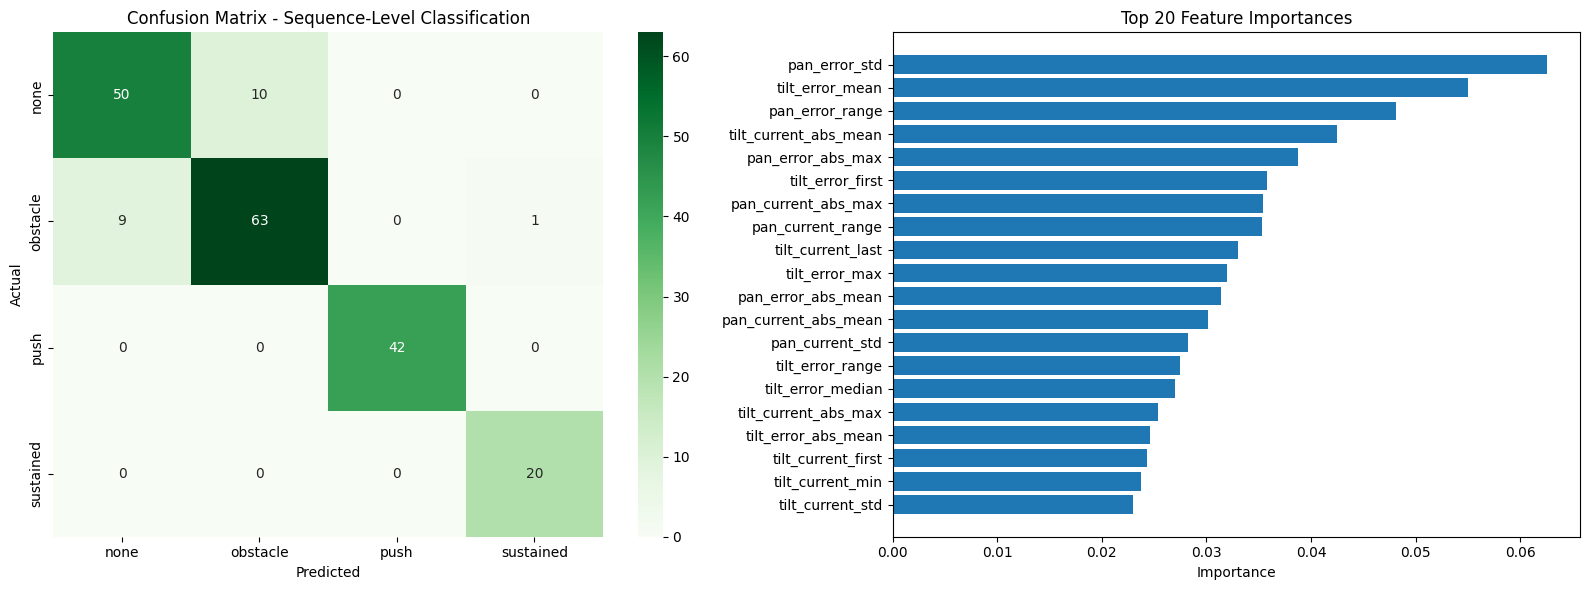


=== Top 10 Most Important Features ===
                  feature  importance
34          pan_error_std    0.062590
22        tilt_error_mean    0.054994
37        pan_error_range    0.048129
10  tilt_current_abs_mean    0.042469
42      pan_error_abs_max    0.038758
28       tilt_error_first    0.035783
20    pan_current_abs_max    0.035393
15      pan_current_range    0.035286
7       tilt_current_last    0.032975
25         tilt_error_max    0.031950


In [ ]:
# Visualize sequence-level results
if 'y_seq_pred_test' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Confusion Matrix
    cm_seq = confusion_matrix(y_seq_test, y_seq_pred_test)
    sns.heatmap(cm_seq, annot=True, fmt='d', cmap='Greens', 
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix - Sequence-Level Classification')
    
    # Feature importance (top 20)
    feature_importance_seq = pd.DataFrame({
        'feature': feature_cols_seq,
        'importance': rf_seq_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    axes[1].barh(feature_importance_seq['feature'], feature_importance_seq['importance'])
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Top 20 Feature Importances')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== Top 10 Most Important Features ===")
    print(feature_importance_seq.head(10))

## Approach 3: LSTM Sequence Classifier

For true sequence modeling, let's use an LSTM (Long Short-Term Memory) neural network that can learn temporal patterns.

In [ ]:
# Prepare sequences for LSTM (pad to same length)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.utils import to_categorical

if 'sequence_id' in combined_df.columns and 'perturbation_type' in combined_df.columns:
    print("=== Preparing Sequences for LSTM ===")
    
    # Group data by sequence
    sequences = []
    sequence_labels_lstm = []
    sequence_ids_lstm = []
    
    for seq_id in combined_df['sequence_id'].unique():
        seq_data = combined_df[combined_df['sequence_id'] == seq_id]
        
        # Extract features for this sequence
        seq_features = seq_data[available_features].values
        sequences.append(seq_features)
        
        # Label (same for entire sequence)
        label = seq_data['perturbation_type'].iloc[0]
        sequence_labels_lstm.append(label)
        sequence_ids_lstm.append(seq_id)
    
    # Encode labels
    y_lstm = label_encoder.transform(sequence_labels_lstm)
    
    # Pad sequences to same length
    max_len = max([len(seq) for seq in sequences])
    print(f"Maximum sequence length: {max_len}")
    print(f"Number of sequences: {len(sequences)}")
    
    # Pad sequences (pad with zeros at the end)
    X_lstm_padded = pad_sequences(sequences, maxlen=max_len, dtype='float32', padding='post')
    
    print(f"Padded sequences shape: {X_lstm_padded.shape}")
    print(f"  (num_sequences, max_length, num_features)")
    
    # Split into train/test (80/20)
    from sklearn.model_selection import train_test_split
    X_lstm_train, X_lstm_test, y_lstm_train, y_lstm_test = train_test_split(
        X_lstm_padded, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
    )
    
    # Convert labels to categorical
    num_classes = len(label_encoder.classes_)
    y_lstm_train_cat = to_categorical(y_lstm_train, num_classes)
    y_lstm_test_cat = to_categorical(y_lstm_test, num_classes)
    
    print(f"\nTrain set: {X_lstm_train.shape[0]} sequences")
    print(f"Test set: {X_lstm_test.shape[0]} sequences")

=== Preparing Sequences for LSTM ===
Maximum sequence length: 220
Number of sequences: 972
Padded sequences shape: (972, 220, 4)
  (num_sequences, max_length, num_features)

Train set: 777 sequences
Test set: 195 sequences
Maximum sequence length: 220
Number of sequences: 972
Padded sequences shape: (972, 220, 4)
  (num_sequences, max_length, num_features)

Train set: 777 sequences
Test set: 195 sequences


In [ ]:
# Build and train LSTM model
if 'X_lstm_train' in locals():
    print("=== Building LSTM Model ===")
    
    model_lstm = Sequential([
        # Masking layer to ignore padded values
        Masking(mask_value=0., input_shape=(max_len, len(available_features))),
        
        # LSTM layers
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        
        # Dense layers
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    
    model_lstm.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(model_lstm.summary())
    
    # Train the model
    print("\n=== Training LSTM ===")
    history_lstm = model_lstm.fit(
        X_lstm_train, y_lstm_train_cat,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=1
    )
    
    # Evaluate
    test_loss, test_acc = model_lstm.evaluate(X_lstm_test, y_lstm_test_cat, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.2%}")

=== Building LSTM Model ===


/Users/pierre/ikaros/Source/Modules/RobotModules/CompliantRobot/TestMapping/.tensorflow_venv/lib/python3.12/site-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 220, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 220, 128)       │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 220, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,716 (467.64 KB)

 Trainable params: 119,716 (467.64 KB)

 Non-trainable params: 0 (0.00 B)

None

=== Training LSTM ===
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.3888 - loss: 1.3092 - val_accuracy: 0.5769 - val_loss: 0.9945
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.3888 - loss: 1.3092 - val_accuracy: 0.5769 - val_loss: 0.9945
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.6626 - loss: 0.8730 - val_accuracy: 0.5769 - val_loss: 0.8439
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.6626 - loss: 0.8730 - val_accuracy: 0.5769 - val_loss: 0.8439
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.7185 - loss: 0.6796 - val_accuracy: 0.6218 - val_loss: 0.7578
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.7185 - loss: 0.6796 - val_accuracy: 0.6218 - val_loss: 0.7578
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.7275 - loss: 0.6345 - val_accuracy: 0.6603 - val_loss: 0.7355
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.7275 - los

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


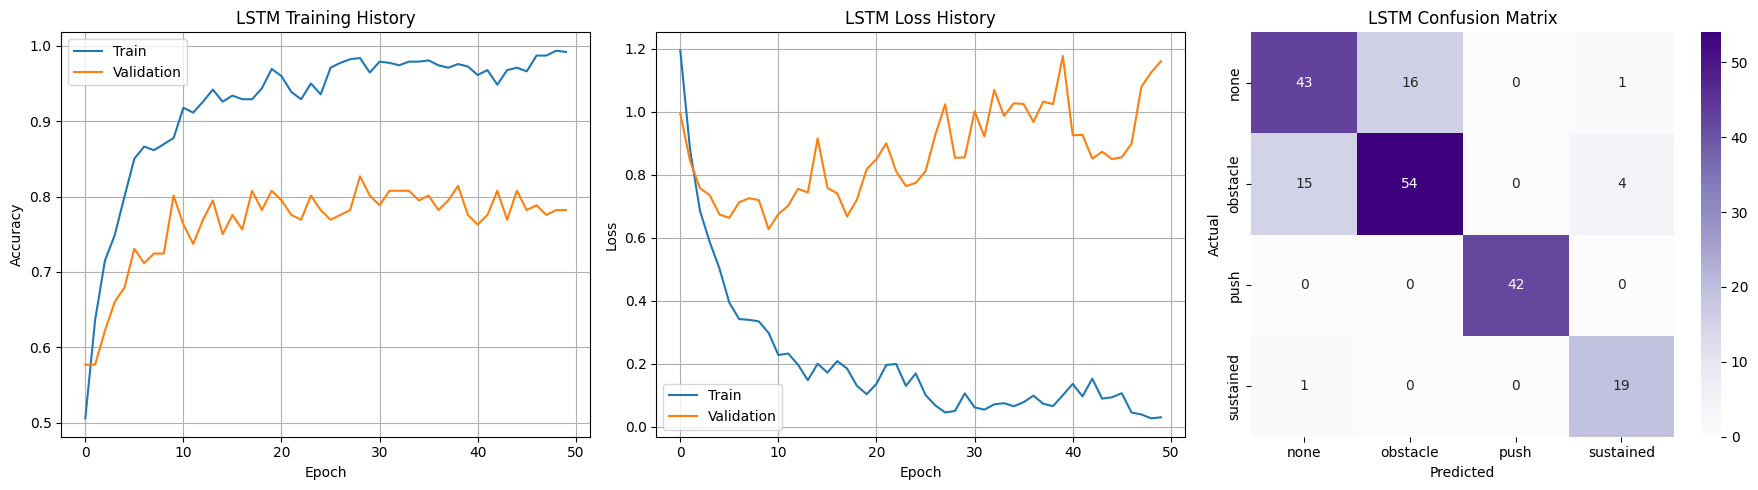


=== LSTM Classification Report ===
              precision    recall  f1-score   support

        none      0.729     0.717     0.723        60
    obstacle      0.771     0.740     0.755        73
        push      1.000     1.000     1.000        42
   sustained      0.792     0.950     0.864        20

    accuracy                          0.810       195
   macro avg      0.823     0.852     0.835       195
weighted avg      0.810     0.810     0.809       195



In [ ]:
# Visualize LSTM training and results
if 'history_lstm' in locals():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Training history
    axes[0].plot(history_lstm.history['accuracy'], label='Train')
    axes[0].plot(history_lstm.history['val_accuracy'], label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('LSTM Training History')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history_lstm.history['loss'], label='Train')
    axes[1].plot(history_lstm.history['val_loss'], label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('LSTM Loss History')
    axes[1].legend()
    axes[1].grid(True)
    
    # Confusion matrix
    y_lstm_pred = model_lstm.predict(X_lstm_test)
    y_lstm_pred_classes = np.argmax(y_lstm_pred, axis=1)
    
    cm_lstm = confusion_matrix(y_lstm_test, y_lstm_pred_classes)
    sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[2])
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')
    axes[2].set_title('LSTM Confusion Matrix')
    
    plt.tight_layout()
    plt.show()
    
    print("\n=== LSTM Classification Report ===")
    print(classification_report(y_lstm_test, y_lstm_pred_classes,
                                target_names=label_encoder.classes_,
                                digits=3))

## Model Comparison and Selection

In [ ]:
# Compare all three approaches
results_comparison = []

if 'test_acc' in locals():
    results_comparison.append({
        'Approach': 'Point-wise RF (sequence-aware split)',
        'Test Accuracy': test_acc,
        'Notes': 'Classifies each time point independently'
    })

if 'seq_test_acc' in locals():
    results_comparison.append({
        'Approach': 'Sequence-level RF (aggregated features)',
        'Test Accuracy': seq_test_acc,
        'Notes': 'Aggregates statistics over entire sequence'
    })

if 'test_acc' in dir() and 'model_lstm' in locals():
    results_comparison.append({
        'Approach': 'LSTM Sequence Classifier',
        'Test Accuracy': test_acc if 'test_acc' not in locals() else model_lstm.evaluate(X_lstm_test, y_lstm_test_cat, verbose=0)[1],
        'Notes': 'True temporal sequence modeling'
    })

if results_comparison:
    comparison_df = pd.DataFrame(results_comparison)
    print("=== Model Comparison ===")
    print(comparison_df.to_string(index=False))
    print("\n" + "="*80)
    print("RECOMMENDATION:")
    print("- Use Sequence-level RF if you need interpretability and fast inference")
    print("- Use LSTM if you need to capture complex temporal dependencies")
    print("- Point-wise RF is simplest but ignores sequence structure within each sequence")

=== Model Comparison ===
                               Approach  Test Accuracy                                      Notes
   Point-wise RF (sequence-aware split)       0.810256   Classifies each time point independently
Sequence-level RF (aggregated features)       0.897436 Aggregates statistics over entire sequence
               LSTM Sequence Classifier       0.810256            True temporal sequence modeling

RECOMMENDATION:
- Use Sequence-level RF if you need interpretability and fast inference
- Use LSTM if you need to capture complex temporal dependencies
- Point-wise RF is simplest but ignores sequence structure within each sequence


## Save Best Model for Deployment

In [ ]:
# Save the best performing model
import pickle
import os

# Choose which model to save based on performance
# For this example, we'll save the sequence-level RF model

if 'rf_seq_model' in locals() and 'scaler_seq' in locals():
    # Create models directory if it doesn't exist
    models_dir = '../../ForceCheck/models'
    os.makedirs(models_dir, exist_ok=True)
    
    # Save sequence-level RF model
    model_path = os.path.join(models_dir, 'sequence_classifier_rf.pkl')
    scaler_path = os.path.join(models_dir, 'sequence_feature_scaler.pkl')
    encoder_path = os.path.join(models_dir, 'sequence_label_encoder.pkl')
    
    with open(model_path, 'wb') as f:#
        pickle.dump(rf_seq_model, f)
    
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler_seq, f)
    
    with open(encoder_path, 'wb') as f:
        pickle.dump(label_encoder, f)
    
    print(f"✓ Saved sequence-level RF model to: {model_path}")
    print(f"✓ Saved feature scaler to: {scaler_path}")
    print(f"✓ Saved label encoder to: {encoder_path}")
    print(f"\nModel info:")
    print(f"  - Test Accuracy: {seq_test_acc:.2%}")
    print(f"  - Number of features: {len(feature_cols_seq)}")
    print(f"  - Classes: {list(label_encoder.classes_)}")

# Optionally save LSTM model
if 'model_lstm' in locals():
    lstm_model_path = os.path.join(models_dir, 'sequence_classifier_lstm.keras')
    model_lstm.save(lstm_model_path)
    print(f"\n✓ Saved LSTM model to: {lstm_model_path}")

✓ Saved sequence-level RF model to: ../../ForceCheck/models/sequence_classifier_rf.pkl
✓ Saved feature scaler to: ../../ForceCheck/models/sequence_feature_scaler.pkl
✓ Saved label encoder to: ../../ForceCheck/models/sequence_label_encoder.pkl

Model info:
  - Test Accuracy: 89.74%
  - Number of features: 44
  - Classes: ['none', 'obstacle', 'push', 'sustained']

✓ Saved LSTM model to: ../../ForceCheck/models/sequence_classifier_lstm.keras


## Sliding Window Model Training

The previous sequence-based model was trained on complete sequences (variable length 34-220 timesteps).
This creates a train/inference mismatch when using a fixed rolling window for real-time classification.

Here we retrain using a sliding window approach:
- Fixed window size matching inference scenario
- Overlapping windows from each sequence
- Better generalization to continuous data streams

In [ ]:
def create_sliding_windows(df, window_size=50, stride=10, feature_cols=None):
    """
    Create sliding windows from sequence data for training.
    
    Args:
        df: DataFrame with sequence_id, perturbation_type, and feature columns
        window_size: Number of timesteps per window
        stride: Number of timesteps to slide the window
        feature_cols: List of feature column names to use
    
    Returns:
        windows_features: List of feature arrays (each is window_size x n_features)
        windows_labels: List of labels for each window
        windows_seq_ids: List of sequence IDs for tracking
    """
    if feature_cols is None:
        feature_cols = ['tilt_current', 'pan_current', 'tilt_error', 'pan_error']
    
    windows_features = []
    windows_labels = []
    windows_seq_ids = []
    
    # Group by sequence
    for seq_id, seq_data in df.groupby('sequence_id'):
        # Get the label for this sequence (should be constant within sequence)
        label = seq_data['perturbation_type'].iloc[0]
        
        # Extract features as numpy array
        features = seq_data[feature_cols].values
        
        # Create sliding windows
        for start_idx in range(0, len(features) - window_size + 1, stride):
            end_idx = start_idx + window_size
            window = features[start_idx:end_idx]
            
            windows_features.append(window)
            windows_labels.append(label)
            windows_seq_ids.append(seq_id)
    
    print(f"Created {len(windows_features)} windows from {df['sequence_id'].nunique()} sequences")
    print(f"Window size: {window_size}, Stride: {stride}")
    
    return windows_features, windows_labels, windows_seq_ids

In [ ]:
# Create sliding windows from the data
# Window size = 50 timesteps (between training min of 34 and mean of 68)
# Stride = 10 (creates overlapping windows for more training data)
WINDOW_SIZE = 20
STRIDE = 5

windows_features, windows_labels, windows_seq_ids = create_sliding_windows(
    combined_df, 
    window_size=WINDOW_SIZE, 
    stride=STRIDE,
    feature_cols=available_features
)

# Convert to numpy arrays
windows_features = np.array(windows_features)
windows_labels = np.array(windows_labels)
windows_seq_ids = np.array(windows_seq_ids)

print(f"\nWindows shape: {windows_features.shape}")
print(f"Labels shape: {windows_labels.shape}")
print(f"\nLabel distribution in windows:")
unique, counts = np.unique(windows_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} ({100*count/len(windows_labels):.1f}%)")

Created 10037 windows from 972 sequences
Window size: 20, Stride: 5

Windows shape: (10037, 20, 4)
Labels shape: (10037,)

Label distribution in windows:
  none: 2680 (26.7%)
  obstacle: 3327 (33.1%)
  push: 2730 (27.2%)
  sustained: 1300 (13.0%)


In [ ]:
# Split data ensuring sequences don't overlap between train and test
# Use GroupShuffleSplit with sequence IDs to maintain separation
gss_window = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Use the sequence IDs as groups
train_idx_w, test_idx_w = next(gss_window.split(windows_features, windows_labels, groups=windows_seq_ids))

X_train_w = windows_features[train_idx_w]
X_test_w = windows_features[test_idx_w]
y_train_w = windows_labels[train_idx_w]
y_test_w = windows_labels[test_idx_w]

print(f"Training windows: {len(X_train_w)}")
print(f"Testing windows: {len(X_test_w)}")
print(f"\nTraining label distribution:")
unique, counts = np.unique(y_train_w, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} ({100*count/len(y_train_w):.1f}%)")
print(f"\nTesting label distribution:")
unique, counts = np.unique(y_test_w, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  {label}: {count} ({100*count/len(y_test_w):.1f}%)")

# Verify no sequence overlap
train_seqs_w = set(windows_seq_ids[train_idx_w])
test_seqs_w = set(windows_seq_ids[test_idx_w])
overlap_w = train_seqs_w.intersection(test_seqs_w)
print(f"\nSequence overlap check: {len(overlap_w)} sequences in both train and test (should be 0)")

Training windows: 7988
Testing windows: 2049

Training label distribution:
  none: 2094 (26.2%)
  obstacle: 2735 (34.2%)
  push: 2184 (27.3%)
  sustained: 975 (12.2%)

Testing label distribution:
  none: 586 (28.6%)
  obstacle: 592 (28.9%)
  push: 546 (26.6%)
  sustained: 325 (15.9%)

Sequence overlap check: 0 sequences in both train and test (should be 0)


In [ ]:
# Now aggregate features for each window using the same create_sequence_features function
print("Aggregating features for each window...")

# Build expected feature names WITHOUT sequence_length
# (sequence_length would be constant during inference, so not useful for classification)
expected_features = []
for feat in available_features:
    expected_features.extend([
        f'{feat}_mean', f'{feat}_std', f'{feat}_min', f'{feat}_max',
        f'{feat}_range', f'{feat}_median', f'{feat}_first', f'{feat}_last',
        f'{feat}_diff_first_last', f'{feat}_abs_max', f'{feat}_abs_mean'
    ])
# NOT including 'sequence_length' - window size is fixed during inference

print(f"Expected number of features: {len(expected_features)}")

def aggregate_window_features(window, feature_names):
    """
    Aggregate features for a single window (numpy array).
    Args:
        window: numpy array of shape (window_size, n_features)
        feature_names: list of feature column names
    Returns:
        dict of aggregated features
    """
    # Convert to DataFrame for easier aggregation
    window_df = pd.DataFrame(window, columns=feature_names)
    return create_sequence_features(window_df, feature_names)

X_train_w_agg_list = []
for window in X_train_w:
    window_dict = aggregate_window_features(window, available_features)
    # Convert to ordered array
    window_features = np.array([window_dict[feat] for feat in expected_features])
    X_train_w_agg_list.append(window_features)

X_test_w_agg_list = []
for window in X_test_w:
    window_dict = aggregate_window_features(window, available_features)
    window_features = np.array([window_dict[feat] for feat in expected_features])
    X_test_w_agg_list.append(window_features)

X_train_w_agg = np.array(X_train_w_agg_list)
X_test_w_agg = np.array(X_test_w_agg_list)

print(f"Aggregated training features shape: {X_train_w_agg.shape}")
print(f"Aggregated testing features shape: {X_test_w_agg.shape}")
print(f"Number of features per window: {X_train_w_agg.shape[1]}")

Aggregating features for each window...
Expected number of features: 44
Aggregated training features shape: (7988, 44)
Aggregated testing features shape: (2049, 44)
Number of features per window: 44


In [ ]:
# Encode labels and scale features
y_train_w_encoded = label_encoder.transform(y_train_w)
y_test_w_encoded = label_encoder.transform(y_test_w)

# Create a new scaler for the sliding window data
scaler_sliding = StandardScaler()
X_train_w_scaled = scaler_sliding.fit_transform(X_train_w_agg)
X_test_w_scaled = scaler_sliding.transform(X_test_w_agg)

print("Data preparation complete!")
print(f"Training set: {X_train_w_scaled.shape[0]} windows")
print(f"Testing set: {X_test_w_scaled.shape[0]} windows")

Data preparation complete!
Training set: 7988 windows
Testing set: 2049 windows


In [ ]:
# Train Random Forest classifier on sliding windows
from sklearn.metrics import accuracy_score, classification_report

print("Training Random Forest on sliding windows...")

rf_sliding_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_sliding_model.fit(X_train_w_scaled, y_train_w_encoded)

# Evaluate on training set
y_train_w_pred = rf_sliding_model.predict(X_train_w_scaled)
train_acc_w = accuracy_score(y_train_w_encoded, y_train_w_pred)

# Evaluate on test set
y_test_w_pred = rf_sliding_model.predict(X_test_w_scaled)
test_acc_w = accuracy_score(y_test_w_encoded, y_test_w_pred)

print(f"\n=== Sliding Window Random Forest Results ===")
print(f"Training Accuracy: {train_acc_w:.4f}")
print(f"Testing Accuracy: {test_acc_w:.4f}")

# Classification report
print(f"\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_w_encoded, y_test_w_pred, 
                          target_names=label_encoder.classes_))

Training Random Forest on sliding windows...

=== Sliding Window Random Forest Results ===
Training Accuracy: 0.9995
Testing Accuracy: 0.8819

=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

        none       0.83      0.79      0.81       586
    obstacle       0.80      0.84      0.82       592
        push       0.98      0.99      0.99       546
   sustained       0.95      0.93      0.94       325

    accuracy                           0.88      2049
   macro avg       0.89      0.89      0.89      2049
weighted avg       0.88      0.88      0.88      2049



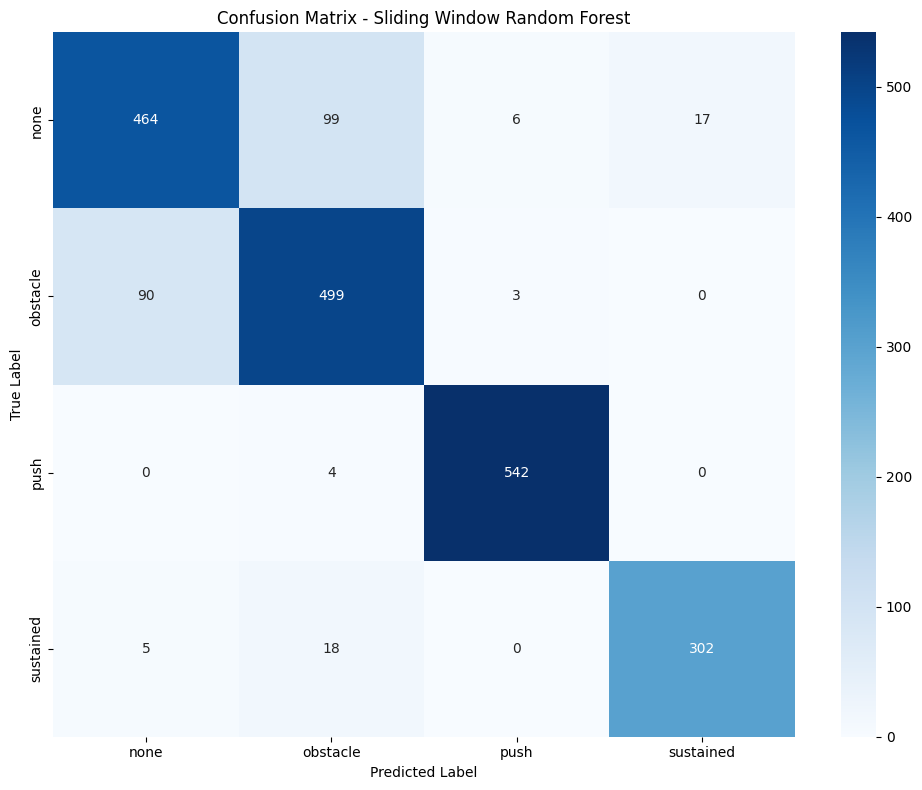


=== Per-Class Accuracy ===
none: 0.7918
obstacle: 0.8429
push: 0.9927
sustained: 0.9292


In [ ]:
# Confusion matrix for sliding window model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_sliding = confusion_matrix(y_test_w_encoded, y_test_w_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_sliding, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Sliding Window Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n=== Per-Class Accuracy ===")
for i, class_name in enumerate(label_encoder.classes_):
    class_acc = cm_sliding[i, i] / cm_sliding[i, :].sum()
    print(f"{class_name}: {class_acc:.4f}")


=== Top 20 Most Important Features ===
                  feature  importance
25         tilt_error_max    0.054556
22        tilt_error_mean    0.054443
27      tilt_error_median    0.040508
43     pan_error_abs_mean    0.038631
38       pan_error_median    0.034647
35          pan_error_min    0.033106
7       tilt_current_last    0.033031
29        tilt_error_last    0.032474
32    tilt_error_abs_mean    0.030666
5     tilt_current_median    0.028885
21   pan_current_abs_mean    0.028427
18       pan_current_last    0.027920
0       tilt_current_mean    0.027180
33         pan_error_mean    0.026679
10  tilt_current_abs_mean    0.026168
20    pan_current_abs_max    0.025460
40         pan_error_last    0.024306
9    tilt_current_abs_max    0.022334
24         tilt_error_min    0.022158
3        tilt_current_max    0.021534


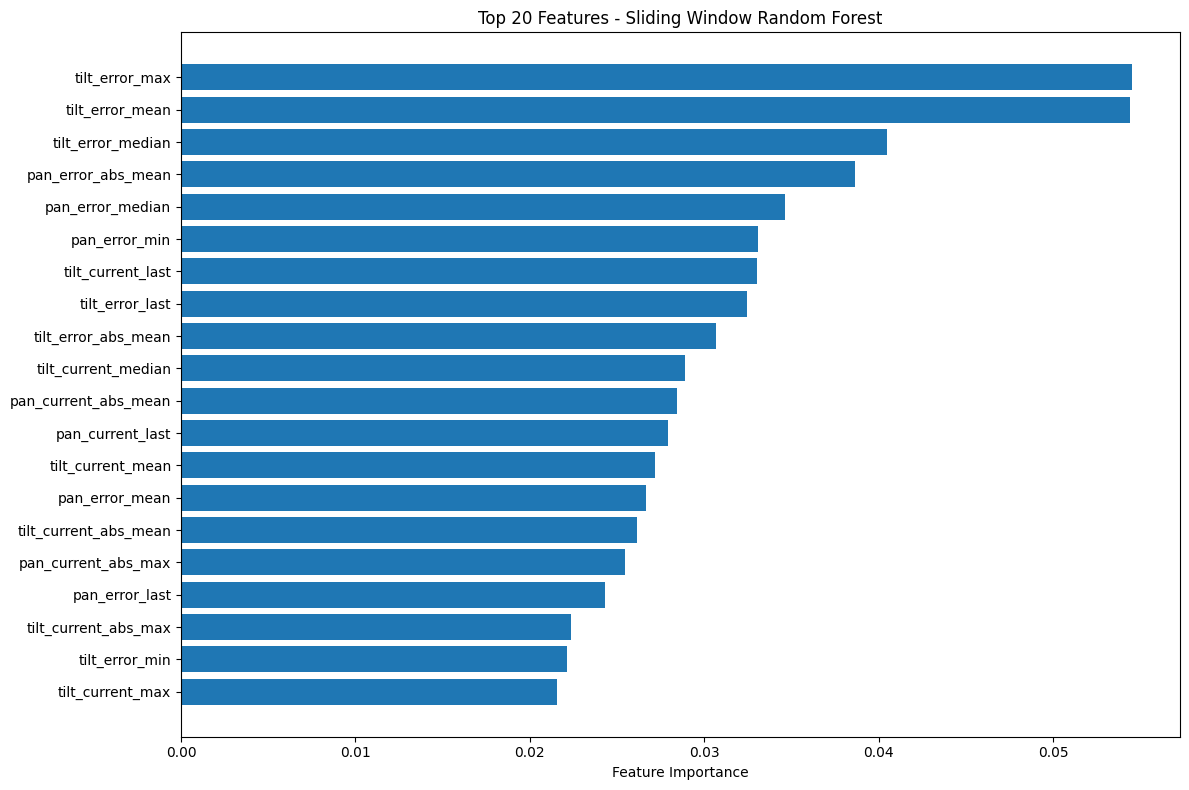

In [ ]:
# Feature importance for sliding window model
feature_importance_sliding = pd.DataFrame({
    'feature': expected_features,
    'importance': rf_sliding_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 20 Most Important Features ===")
print(feature_importance_sliding.head(20))

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_20 = feature_importance_sliding.head(20)
plt.barh(range(len(top_20)), top_20['importance'])
plt.yticks(range(len(top_20)), top_20['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Features - Sliding Window Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Save Sliding Window Model

Save the new sliding window-based model with updated filenames to distinguish from the sequence-based model.

In [ ]:
# Save the sliding window model and associated objects
import os
import pickle

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save with distinct filenames
sliding_model_path = os.path.join(models_dir, 'sliding_window_classifier_rf.pkl')
sliding_scaler_path = os.path.join(models_dir, 'sliding_window_scaler.pkl')
# Label encoder is the same, but save a copy for consistency
sliding_encoder_path = os.path.join(models_dir, 'sliding_window_label_encoder.pkl')

with open(sliding_model_path, 'wb') as f:
    pickle.dump(rf_sliding_model, f)
print(f"Saved model to {sliding_model_path}")

with open(sliding_scaler_path, 'wb') as f:
    pickle.dump(scaler_sliding, f)
print(f"Saved scaler to {sliding_scaler_path}")

with open(sliding_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Saved label encoder to {sliding_encoder_path}")

# Also save metadata about the window configuration
metadata = {
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'feature_names': expected_features,
    'raw_feature_names': available_features,
    'classes': label_encoder.classes_.tolist(),
    'train_accuracy': train_acc_w,
    'test_accuracy': test_acc_w,
    'n_training_windows': len(X_train_w_scaled),
    'n_testing_windows': len(X_test_w_scaled)
}

metadata_path = os.path.join(models_dir, 'sliding_window_metadata.json')
import json
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Saved metadata to {metadata_path}")

print("\n=== Model Summary ===")
print(f"Window size: {WINDOW_SIZE} timesteps")
print(f"Stride: {STRIDE} timesteps")
print(f"Training accuracy: {train_acc_w:.4f}")
print(f"Testing accuracy: {test_acc_w:.4f}")
print(f"Number of features: {len(expected_features)}")
print(f"Classes: {label_encoder.classes_}")

Saved model to models/sliding_window_classifier_rf.pkl
Saved scaler to models/sliding_window_scaler.pkl
Saved label encoder to models/sliding_window_label_encoder.pkl
Saved metadata to models/sliding_window_metadata.json

=== Model Summary ===
Window size: 20 timesteps
Stride: 5 timesteps
Training accuracy: 0.9995
Testing accuracy: 0.8819
Number of features: 44
Classes: ['none' 'obstacle' 'push' 'sustained']
